# Clustering jerárquico con huecos: sueño, salud y estilo de vida

Completa las celdas siguientes para aplicar:

- clustering jerárquico
- dendrograma
- análisis de clústeres
- comparación con K-Means
- Utiliza para la resolución https://scikit-learn.org/stable/ y https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html

>El origen del Dataset es https://www.kaggle.com/

## Contexto del dataset

El dataset recoge hábitos de sueño, salud y estilo de vida de aproximadamente 400 personas. Cada fila representa un individuo. Las variables que usaremos son:

| Variable | Tipo | Rango / Valores | Qué mide |
|---|---|---|---|
| Age | Numérica | 27 – 59 | Edad en años |
| Sleep Duration | Numérica | 5.8 – 8.5 | Horas de sueño por noche |
| Quality of Sleep | Numérica | 1 – 10 | Calidad subjetiva del sueño |
| Physical Activity Level | Numérica | 30 – 90 | Minutos de actividad física diaria |
| Stress Level | Numérica | 1 – 10 | Nivel de estrés autopercibido |
| Heart Rate | Numérica | 65 – 86 | Pulsaciones en reposo (bpm) |
| Daily Steps | Numérica | 3.000 – 10.000 | Pasos diarios |

También existen variables categóricas como `Gender` y `Sleep Disorder` que no entran en el clustering pero pueden usarse para interpretar los grupos.

---

**Antes de ejecutar nada, analiza:**  
¿Qué variable crees que tendrá más peso a la hora de separar los grupos?  
¿Esperas que el género influya en los clústeres resultantes?

Anota tu hipótesis aquí y compárala con los resultados al final.

> *Mi hipótesis:*

## 1. Importación de librerías

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

## 2. Carga del dataset

In [11]:
df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


## 2b. Comprobación y tratamiento de valores nulos

Antes de continuar, verifica si el dataset tiene valores que deban tener un tratamiento específico.  
Esta decisión afecta a todo el análisis posterior.

In [12]:
# Nulos por columna
print(df.isnull().sum())

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64


In [13]:
# ¿Qué porcentaje representa cada uno?
print((df.isnull().sum() / len(df) * 100).round(2))

Person ID                   0.00
Gender                      0.00
Age                         0.00
Occupation                  0.00
Sleep Duration              0.00
Quality of Sleep            0.00
Physical Activity Level     0.00
Stress Level                0.00
BMI Category                0.00
Blood Pressure              0.00
Heart Rate                  0.00
Daily Steps                 0.00
Sleep Disorder             58.56
dtype: float64


In [14]:
# Decide una estrategia y completa:
# Opción A — eliminar filas con nulos
# Opción B — imputar con la media
# Opción C — imputar con la mediana

df.drop(columns=["Sleep Disorder"], inplace=True) # Opción C
# df[columnas] = df[columnas].fillna(df[columnas].median())  # Opción B o C

# Comprobación final: debe dar 0 en todas las columnas
print("Nulos restantes:", df.isnull().sum().sum())

Nulos restantes: 0


## 3. Exploración inicial

In [15]:
print("Filas y columnas:", df.shape)
print(df.columns.tolist())

Filas y columnas: (374, 12)
['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps']


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
dtypes: float64(1), int64(7), object(4)
memory usage: 35.2+ KB


## 4. Selección de variables

Usa estas variables numéricas:
- Age
- Sleep Duration
- Quality of Sleep
- Physical Activity Level
- Stress Level
- Heart Rate
- Daily Steps

In [17]:
columnas = [
    "Age",
    "Daily Steps",
    "Sleep Duration",
    "Quality of Sleep",
    "Stress Level",
    "Physical Activity Level",
]

X = df[columnas]
X.head()

,Age,Daily Steps,Sleep Duration,Quality of Sleep,Stress Level,Physical Activity Level
0,27,4200,6.1,6,6,42
1,28,10000,6.2,6,8,60
2,28,10000,6.2,6,8,60
3,28,3000,5.9,4,8,30
4,28,3000,5.9,4,8,30


## 5. Escalado

In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 6. Matriz de enlace

In [20]:
Z = linkage(X_scaled, method="ward")
Z[:5]

array([[  1.,   2.,   0.,   2.],
       [ 10.,  12.,   0.,   2.],
       [ 13.,  14.,   0.,   2.],
       [ 15., 376.,   0.,   3.],
       [ 17., 377.,   0.,   4.]])

## 7. Dendrograma

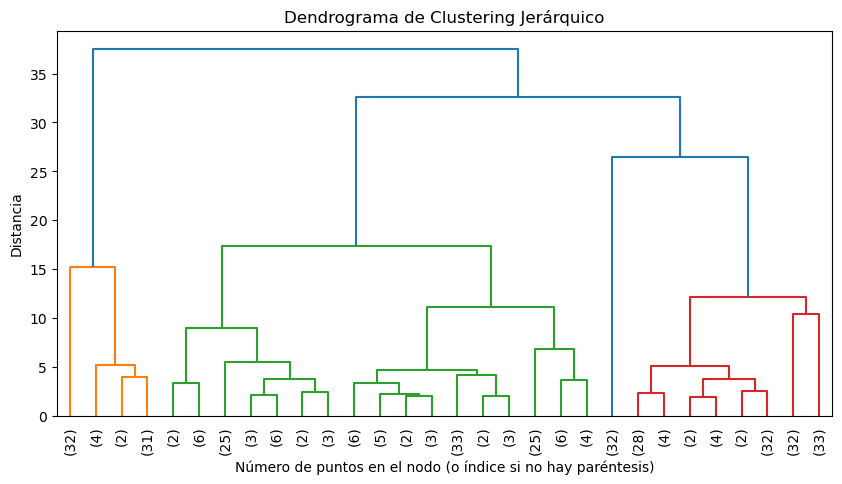

In [23]:
plt.figure(figsize=(10, 5))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90, leaf_font_size=10)
plt.title("Dendrograma de Clustering Jerárquico")
plt.ylabel("Distancia")
plt.xlabel("Número de puntos en el nodo (o índice si no hay paréntesis)")
plt.show()

## 8. Número de clústeres

A partir del dendrograma, crea 3 clústeres.

In [24]:
clusters_h = fcluster(Z, t=1.5, criterion="distance")
df["cluster_jerarquico"] = clusters_h
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,cluster_jerarquico
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,11
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,6
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,6
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,13
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,13


## 9. Tamaño de cada clúster

In [25]:
df["cluster_jerarquico"].shape

(374,)

In [32]:
df["cluster_jerarquico"].head()

0    11
1     6
2     6
3    13
4    13
Name: cluster_jerarquico, dtype: int32

## 10. Perfil medio de cada clúster

In [34]:
perfil_h = df.groupby("cluster_jerarquico")[columnas].mean().round(2)
perfil_h

,Age,Daily Steps,Sleep Duration,Quality of Sleep,Stress Level,Physical Activity Level
cluster_jerarquico,,,,,,
1,52.78,5000.00,8.43,9.00,3.00,30.00
2,55.00,5000.00,8.10,9.00,4.00,75.00
3,49.00,3700.00,8.10,9.00,3.00,85.00
4,56.00,10000.00,8.20,9.00,3.00,90.00
5,58.23,7000.00,8.09,9.00,3.00,75.00
6,28.00,10000.00,6.20,6.00,8.00,60.00
7,29.00,8000.00,6.03,6.00,8.00,30.00
8,32.32,5000.00,6.06,6.00,8.00,30.00
9,37.00,4533.33,6.57,5.00,7.00,36.67


## 11. Relación con género

In [35]:
pd.crosstab(df["cluster_jerarquico"], df["Gender"], normalize="index").round(3)

Gender,Female,Male
cluster_jerarquico,,
1,1.000,0.000
2,1.000,0.000
3,0.000,1.000
4,1.000,0.000
5,1.000,0.000
6,0.000,1.000
7,0.000,1.000
8,0.000,1.000
9,0.000,1.000


## 12. K-Means

In [36]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_k = kmeans.fit_predict(X_scaled)

df["cluster_kmeans"] = clusters_k

## 13. Perfil medio en K-Means

In [38]:
perfil_k = df.groupby("cluster_kmeans")[columnas].mean().round(2)
perfil_k

,Age,Daily Steps,Sleep Duration,Quality of Sleep,Stress Level,Physical Activity Level
cluster_kmeans,,,,,,
0,39.47,5552.34,6.41,6.22,6.51,40.98
1,39.05,8047.46,7.22,7.45,5.49,74.01
2,55.28,6005.80,8.25,9.00,3.03,54.86


## 14. Comparación entre métodos: Matriz de Confusión

> **Nota importante:** los números de clúster asignados por cada algoritmo son arbitrarios. El clúster "1" del jerárquico puede contener los mismos individuos que el clúster "2" de K-Means aunque sean el mismo grupo en la práctica. Interpreta la matriz fijándote en la **concentración de valores**, no en que coincidan los números.

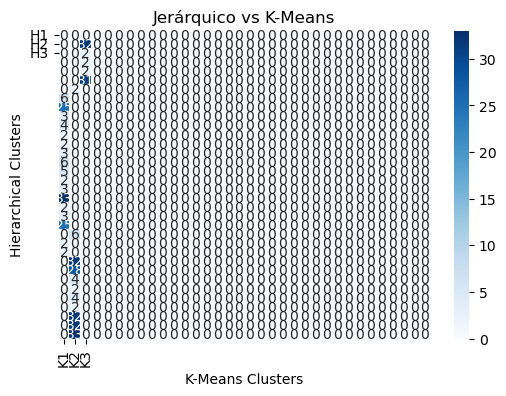

In [40]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Construye la matriz cruzando ambos métodos
matriz = confusion_matrix(df["cluster_jerarquico"], df["cluster_kmeans"])

# Visualización
plt.figure(figsize=(6, 4))
sns.heatmap(
    matriz,
    annot= True,
    fmt="d",
    cmap="Blues",
    xticklabels=["K1", "K2", "K3"],
    yticklabels=["H1", "H2", "H3"]
)
plt.xlabel("K-Means Clusters")
plt.ylabel("Hierarchical Clusters")
plt.title("Jerárquico vs K-Means")
plt.show()

**Reflexiona:** ¿Qué significa que haya valores altos fuera de la diagonal?  
¿Coinciden bien los dos métodos o hay grupos que se mezclan?

> *Mi respuesta:*

## 15. Visualización

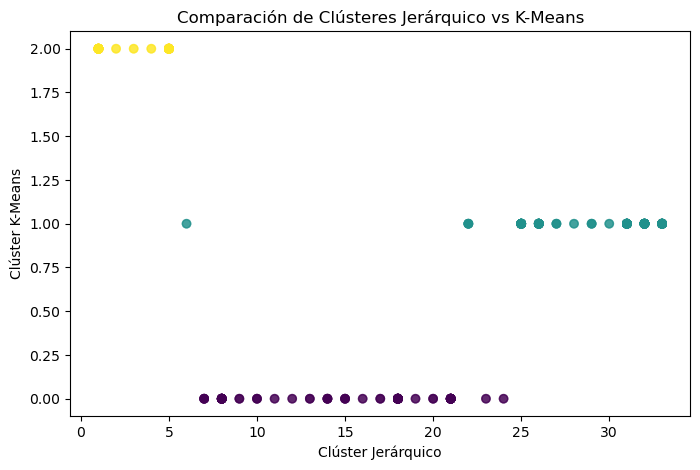

In [41]:
plt.figure(figsize=(8, 5))
plt.scatter(df["cluster_jerarquico"], df["cluster_kmeans"], c=df["cluster_kmeans"], cmap="viridis", alpha=0.6)
plt.xlabel("Clúster Jerárquico")
plt.ylabel("Clúster K-Means")
plt.title("Comparación de Clústeres Jerárquico vs K-Means")
plt.show()

## 16. Cuestiones finales

Responde:

1. ¿Cuántos clústeres observas en el dendrograma?
2. ¿Cómo describirías cada grupo?
3. ¿Qué variables distinguen mejor unos grupos de otros?
4. ¿Coinciden mucho los grupos jerárquicos y los de K-Means?
5. ¿Crees que las personas se agrupan más por género o por hábitos?
6. ¿Se cumplió tu hipótesis inicial sobre qué variable tendría más peso?